# Étude d'ablation — les quatre configurations

Ce notebook **n'exécute aucune simulation** : il lit les artefacts d'une
campagne déjà produite.

```bash
python main.py run --config experiments/ablation.yaml
```

La question à laquelle il répond : *l'écart entre Nearest et BRAM-EV Full vient
de quel composant ?* L'échelle d'ablation n'ajoute qu'un composant à la fois,
sur le **même** monde (même graine, même grille, même flotte, mêmes tirages de
comportement) :

| Configuration | Méthode | Multi-stations | Réputation | Adaptation |
| --- | --- | :-: | :-: | :-: |
| Nearest | `greedy` | non | non | non |
| Multi-Station Only | `multistation` | oui | non | non |
| Multi-Station + Reputation | `multistation_rep` | oui | oui | non |
| BRAM-EV Full | `bramev` | oui | oui | oui |

L'écart entre deux barreaux consécutifs *est* la contribution du composant
ajouté. Le plan est déclaré une seule fois, dans
`src/experiments/methods.py` — les variantes de BRAM-EV sont traitées par
`ablation_variants.ipynb`.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

import pandas as pd
from IPython.display import Image, display

import src.experiments.methods as methods
from src.pipeline import ablation, figures
from src.pipeline.store import RunStore

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 40)

## Choix du run

Une campagne ne porte pas forcément les quatre barreaux :
`latest_with_methods` prend le run le plus récent qui les contient tous, et dit
ce que contiennent les autres s'il n'en trouve aucun. Pour cibler un run précis :
`RunStore.open('../results_grid/<run>')`.

In [2]:
for path in RunStore.list_runs('../results_grid'):
    present = sorted({row['method'] for row in RunStore(path).read_summary()})
    print(f"{path.name}\n    {', '.join(present) or 'aucun cas'}")

20260905T231932Z_seed42_smoke
    bramev, bramev_event_score, bramev_fixed_alpha, bramev_global_rep, bramev_nearest_offer, greedy, multistation, multistation_rep
20260905T232424Z_seed42_ablation
    bramev, greedy, multistation, multistation_rep
20260905T232447Z_seed42_ablation-variants
    bramev, bramev_event_score, bramev_fixed_alpha, bramev_global_rep, bramev_nearest_offer


In [3]:
store = RunStore.latest_with_methods(methods.LADDER, '../results_grid')
params = store.read_params()
manifest = store.read_manifest()

print(store.root)
print(params.describe())
print(f"graine={params.seed} | commit={manifest['git_commit']} | "
      f"cas={manifest['nb_cases_done']}/{manifest['nb_cases_planned']}")

../results_grid/20260905T232424Z_seed42_ablation
seed=42 | scénarios=['optimistic', 'balance', 'pessimistic'] | flottes=[50, 100, 150, 200, 250] | méthodes=['greedy', 'multistation', 'multistation_rep', 'bramev'] | 1440 slots (5.0 j) | 40 stations / 4 sociétés | horizon de réservation [0, 12] slots | 60 runs
graine=42 | commit=0cfda3f6a7bacca72d18a69153f7248e40e38be9 | cas=60/60


## Ce qui est réellement activé

Premier contrôle, avant toute lecture de résultat : les drapeaux effectivement
appliqués. Ils voyagent depuis le registre jusqu'à `summary.csv`
(`src/pipeline/tables.py`), donc cette table dit ce que la campagne a fait —
pas ce qu'elle était censée faire.

Un barreau qui ne bascule pas exactement un composant invaliderait toute
l'attribution des gains.

In [4]:
summary = pd.read_csv(store.summary_path)

ORDRE = list(methods.LADDER)
summary['method'] = pd.Categorical(summary['method'], ORDRE + [
    m for m in summary['method'].unique() if m not in ORDRE], ordered=True)

ladder = summary[summary['method'].isin(ORDRE)].copy()

plan = (ladder[['method', 'method_label', 'broadcast', 'reputation',
                'adaptation', 'offer_choice', 'alpha_mode',
                'reputation_scope', 'score_weighting']]
        .drop_duplicates()
        .sort_values('method')
        .set_index('method'))
plan

,method_label,broadcast,reputation,adaptation,offer_choice,alpha_mode,reputation_scope,score_weighting
method,,,,,,,,
greedy,Nearest,False,False,False,utility,sampled,society,duration
multistation,Multi-Station Only,True,False,False,utility,sampled,society,duration
multistation_rep,Multi-Station + Reputation,True,True,False,utility,sampled,society,duration
bramev,BRAM-EV Full,True,True,True,utility,sampled,society,duration


In [5]:
# Un seul composant change d'un barreau au suivant, et les mécanismes internes
# restent ceux de BRAM-EV tout au long : sinon un barreau mélangerait deux effets.
composants = ['broadcast', 'reputation', 'adaptation']
mecanismes = ['offer_choice', 'alpha_mode', 'reputation_scope', 'score_weighting']

for avant, apres, libelle in methods.LADDER_STEPS:
    a, b = plan.loc[avant], plan.loc[apres]
    change = [c for c in composants if a[c] != b[c]]
    derive = [m for m in mecanismes if a[m] != b[m]]
    etat = 'OK' if (len(change) == 1 and not derive) else 'ANOMALIE'
    print(f"{etat:9} {avant:18} -> {apres:18} {libelle:26} "
          f"change={change} mécanismes_dérivés={derive}")

OK        greedy             -> multistation       Recherche multi-stations   change=['broadcast'] mécanismes_dérivés=[]
OK        multistation       -> multistation_rep   Réputation                 change=['reputation'] mécanismes_dérivés=[]
OK        multistation_rep   -> bramev             Adaptation entre stations  change=['adaptation'] mécanismes_dérivés=[]


In [6]:
# Décomposition calculée à la volée depuis summary.csv. Le pipeline persiste
# exactement les mêmes tables (`ablation.csv`, `ablation_mean.csv`) et les
# réécrit à chaque cas ; les recalculer ici rend le notebook utilisable sur une
# campagne encore en cours, interrompue, ou antérieure à l'étude d'ablation.
detail = pd.DataFrame(ablation.detail_rows(summary.to_dict('records')))
moyennes = pd.DataFrame(ablation.mean_rows(detail.to_dict('records')))

print(f"{len(detail)} écarts calculés sur "
      f"{detail[['scenario', 'nb_cars']].drop_duplicates().shape[0]} mondes")

675 écarts calculés sur 15 mondes


## Les quatre barreaux côte à côte

Une ligne par monde (scénario x flotte), une colonne par barreau. C'est la
lecture brute : la progression le long de l'échelle, avant toute soustraction.

In [7]:
METRIQUES = ['exact_satisfaction', 'rate_abs', 'mean_service_rate',
             'slot_waste_rate', 'nb_reservations', 'mean_waiting_time_min',
             'mean_offers_per_demand', 'total_ms_mean']

niveaux = ladder.pivot_table(index=['scenario', 'nb_cars'], columns='method',
                             values=METRIQUES, observed=True)
niveaux

exact_satisfaction                                       mean_offers_per_demand                                      mean_service_rate  \
method                          greedy multistation multistation_rep  bramev                 greedy multistation multistation_rep bramev            greedy   
scenario    nb_cars                                                                                                                                          
balance     50                  0.7982       0.7990           0.7990  0.7991                  0.996        6.202            6.206  6.224            0.0378   
            100                 0.7939       0.8077           0.8078  0.8080                  0.996        6.086            6.035  6.067            0.0747   
            150                 0.7590       0.8034           0.8024  0.8031                  0.991        5.935            6.006  6.030            0.1089   
            200                 0.7003       0.7943           0.7955  0.7953                  0.962        6.089            6.008  6.020            0.1409   
            250                 0.6588       0.7970           0.7975  0.7968                  0.953        6.141            6.139  6.157            0.1731   
optimistic  50                  0.8959       0.8973           0.8971  0.8975                  0.991        6.217            6.199  6.182            0.0399   
            100                 0.8990       0.9139           0.9133  0.9137                  0.994        6.223            6.124  6.109            0.0784   
            150                 0.8710       0.9082           0.9086  0.9086                  0.988        6.140            6.180  6.181            0.1151   
            200                 0.8243       0.9046           0.9035  0.9040                  0.987        6.198            6.174  6.175            0.1505   
            250                 0.7813       0.8991           0.8996  0.8992                  0.965        6.168            6.224  6.198            0.1848   
pessimistic 50                  0.8089       0.8108           0.8114  0.8115                  0.997        6.225            6.148  6.167            0.0362   
            100                 0.7613       0.7859           0.7861  0.7858                  0.995        6.130            6.096  6.207            0.0717   
            150                 0.7006       0.7798           0.7782  0.7785                  0.985        6.237            6.183  6.184            0.1024   
            200                 0.6643       0.7747           0.7752  0.7747                  0.958        6.167            6.209  6.244            0.1316   
            250                 0.6220       0.7798           0.7792  0.7793                  0.947        6.244            6.195  6.225            0.1586   

                                                          mean_waiting_time_min                                      nb_reservations               \
method              multistation multistation_rep  bramev                greedy multistation multistation_rep bramev          greedy multistation   
scenario    nb_cars                                                                                                                                 
balance     50            0.0380           0.0381  0.0380                 0.462        0.420            0.372  0.360           488.0        489.0   
            100           0.0748           0.0749  0.0750                 3.954        0.756            0.720  0.678           962.0        955.0   
            150           0.1097           0.1100  0.1097                11.322        1.374            1.248  1.206          1480.0       1430.0   
            200           0.1433           0.1443  0.1439                22.704        2.016            2.016  1.926          2117.0       1923.0   
            250           0.1793           0.1787  0.1791                33.498        2.952            2.508  2.988          2715.0

In [8]:
# Moyenne sur tous les mondes du run : la vue d'ensemble en une ligne par barreau.
(ladder.groupby('method', observed=True)[METRIQUES]
       .mean()
       .rename(index=methods.label)
       .round(4))

,exact_satisfaction,rate_abs,mean_service_rate,slot_waste_rate,nb_reservations,mean_waiting_time_min,mean_offers_per_demand,total_ms_mean
method,,,,,,,,
Nearest,0.7693,0.1765,0.1070,0.4141,1652.2000,14.3996,0.9803,105.0072
Multi-Station Only,0.8304,0.1764,0.1089,0.4153,1530.6667,1.3596,6.1601,1571.9112
Multi-Station + Reputation,0.8303,0.1765,0.1090,0.4154,1529.5333,1.2764,6.1417,1587.7867
BRAM-EV Full,0.8303,0.1764,0.1090,0.4154,1530.4000,1.3180,6.1580,1582.3613


## Contribution de chaque composant

`ablation_mean.csv` est écrit par le pipeline à chaque campagne
(`src/pipeline/ablation.py`). Chaque ligne est un couple (composant, métrique) :

* `mean_delta` / `mean_delta_pct` — l'écart moyen au barreau précédent ;
* `share_improved` — la **part des mondes** où le composant améliore la
  métrique, sa direction étant déclarée par métrique (moins de no-shows est un
  gain, moins de satisfaction n'en est pas un).

C'est `share_improved` qui compte : un composant qui n'aide que la moitié des
mondes n'a pas de contribution robuste, quelle que soit sa moyenne.

In [9]:
print(ablation.render_mean_table(moyennes.to_dict('records')))

Composant                  Satisfaction exacte   Taux de no-show   Taux de service  Slots réservés perdus  Réservations confirmées
-------------------------  -------------------  ----------------  ----------------  ---------------------  -----------------------

Échelle d'ablation (contribution du composant ajouté)
Recherche multi-stations          +8.7% (100%)       +0.2% (53%)       +1.4% (87%)            +0.5% (33%)               -5.0% (7%)
Réputation                         -0.0% (53%)       +0.0% (20%)       +0.1% (47%)            +0.0% (53%)              -0.0% (20%)
Adaptation entre stations          +0.0% (60%)       -0.0% (40%)       -0.0% (53%)            -0.0% (53%)              +0.0% (33%)

Lecture : écart relatif moyen sur tous les mondes du run (part des mondes où le composant améliore la métrique).


In [10]:
echelle = moyennes[moyennes['kind'] == 'ladder']

contributions = echelle.pivot_table(
    index='component', columns='metric_label',
    values=['mean_delta_pct', 'share_improved'])
contributions.round(3)

mean_delta_pct                                                                                                              \
metric_label              Attente moyenne Besoins satisfaits Demandes rejetées Distance moyenne Latence bout-en-bout No-shows Réservations confirmées   
component                                                                                                                                               
Adaptation entre stations           1.154             -0.001            22.983            0.291                0.433   -0.007                   0.040   
Recherche multi-stations          -79.018              7.703          1283.052            7.946             1190.624   -4.797                  -4.961   
Réputation                         -5.634             -0.002            79.047            0.062                0.382    0.007                  -0.035   

                                                                                                                                                 \
metric_label              Satisfaction exacte Slots réservés perdus Taux d'occupation Taux de confirmation Taux de no-show Taux de présentation   
component                                                                                                                                         
Adaptation entre stations               0.005                -0.002             0.078               -0.119          -0.044               -0.027   
Recherche multi-stations                8.650                 0.463             1.641                1.435           0.175                0.031   
Réputation                             -0.008                 0.017            -0.036                0.040           0.041               -0.019   

                                                           share_improved                                                                                      \
metric_label              Taux de service Temps de calcul Attente moyenne Besoins satisfaits Demandes rejetées Distance moyenne Latence bout-en-bout No-shows   
component                                                                                                                                                       
Adaptation entre stations          -0.014          -0.007           0.467              0.533             0.267            0.533                0.533    0.267   
Recherche multi-stations            1.374         722.736           1.000              1.000             0.067            0.067                0.000    0.800   
Réputation                          0.098           1.456           0.800              0.467             0.533            0.467                0.400    0.200   

                                                                                                                                                    \
metric_label              Réservations confirmées Satisfaction exacte Slots réservés perdus Taux d'occupation Taux de confirmation Taux de no-show   
component                                                                                                                                            
Adaptation entre stations                   0.333               0.600                 0.533             0.533                0.067           0.400   
Recherche multi-stations                    0.067               1.000                 0.333             0.867                0.733           0.533   
Réputation                                  0.200               0.533                 0.533             0.467                0.467           0.200   

                                                                                
metric_label              Taux de présentation Taux de service Temps de calcul  
component                                                                       
Adaptation entre stations                0.333           0.533           0.533  
Recherche multi-stations         

### Les contributions somment-elles à l'écart total ?

Les trois écarts consécutifs doivent reconstituer l'écart Nearest -> BRAM-EV
Full, monde par monde. Un résidu non nul signalerait un barreau manquant ou un
`summary.csv` incohérent.

In [11]:
pas = detail[(detail['kind'] == 'ladder') &
             (detail['metric'] == 'exact_satisfaction')]

somme = (pas.groupby(['scenario', 'nb_cars'])['delta'].sum()
            .rename('somme_des_contributions'))

extremes = ladder.pivot_table(index=['scenario', 'nb_cars'], columns='method',
                              values='exact_satisfaction', observed=True)
total = (extremes[methods.LADDER[-1]] - extremes[methods.LADDER[0]]
         ).rename('ecart_total')

controle = pd.concat([somme, total], axis=1)
controle['residu'] = (controle['somme_des_contributions']
                      - controle['ecart_total']).abs()
print(f"résidu maximal : {controle['residu'].max():.2e}")
controle.round(6)

résidu maximal : 8.33e-17


somme_des_contributions  ecart_total  residu
scenario    nb_cars                                              
balance     50                        0.0009       0.0009     0.0
            100                       0.0141       0.0141     0.0
            150                       0.0441       0.0441     0.0
            200                       0.0950       0.0950     0.0
            250                       0.1380       0.1380     0.0
optimistic  50                        0.0016       0.0016     0.0
            100                       0.0147       0.0147     0.0
            150                       0.0376       0.0376     0.0
            200                       0.0797       0.0797     0.0
            250                       0.1179       0.1179     0.0
pessimistic 50                        0.0026       0.0026     0.0
            100                       0.0245       0.0245     0.0
            150                       0.0779       0.0779     0.0
            200                       0.1104       0.1104     0.0
            250                       0.1573       0.1573     0.0

## Dispersion : la moyenne cache quoi ?

Un écart moyen positif peut n'être porté que par un monde. Voici la
distribution des contributions par composant, sur toutes les tailles de flotte
et tous les scénarios.

In [12]:
for metrique in ['exact_satisfaction', 'rate_abs', 'mean_service_rate']:
    bloc = detail[(detail['kind'] == 'ladder') & (detail['metric'] == metrique)]
    if bloc.empty:
        continue
    libelle = bloc['metric_label'].iloc[0]
    print(f"\n=== {libelle} — écart au barreau précédent ===")
    stats = (bloc.groupby('component')['delta']
                 .agg(['count', 'min', 'median', 'mean', 'max'])
                 .round(6))
    stats['mondes_améliorés'] = bloc.groupby('component')['improvement'].mean().round(3)
    display(stats)


=== Satisfaction exacte — écart au barreau précédent ===


,count,min,median,mean,max,mondes_améliorés
component,,,,,,
Adaptation entre stations,15,-0.0007,0.0001,0.000047,0.0007,0.600
Recherche multi-stations,15,0.0008,0.0444,0.061113,0.1578,1.000
Réputation,15,-0.0016,0.0001,-0.000073,0.0012,0.533



=== Taux de no-show — écart au barreau précédent ===


,count,min,median,mean,max,mondes_améliorés
component,,,,,,
Adaptation entre stations,15,-0.0014,0.0000,-0.000107,0.0010,0.400
Recherche multi-stations,15,-0.0058,-0.0004,-0.000120,0.0042,0.533
Réputation,15,-0.0018,0.0000,0.000140,0.0028,0.200



=== Taux de service — écart au barreau précédent ===


,count,min,median,mean,max,mondes_améliorés
component,,,,,,
Adaptation entre stations,15,-0.0007,0.0001,-0.000013,0.0005,0.533
Recherche multi-stations,15,-0.0004,0.0008,0.001973,0.0110,0.867
Réputation,15,-0.0007,0.0000,0.000087,0.0010,0.467


In [13]:
# Le composant aide-t-il davantage quand la ressource devient rare ?
# Une contribution qui croît avec la flotte est une contribution qui porte
# sur la congestion, non sur le hasard du tirage.
(detail[(detail['kind'] == 'ladder') &
        (detail['metric'] == 'exact_satisfaction')]
 .pivot_table(index='component', columns='nb_cars', values='delta_pct')
 .round(2))

nb_cars,50,100,150,200,250
component,,,,,
Adaptation entre stations,0.02,0.01,0.04,-0.01,-0.04
Recherche multi-stations,0.16,2.21,7.14,13.26,20.47
Réputation,0.02,-0.01,-0.10,0.03,0.01


## Figures

Déjà écrites par le pipeline dans `figures/`. Les régénérer après avoir modifié
`src/pipeline/figures.py` :

```bash
python main.py report --latest
```

ablation_components.png


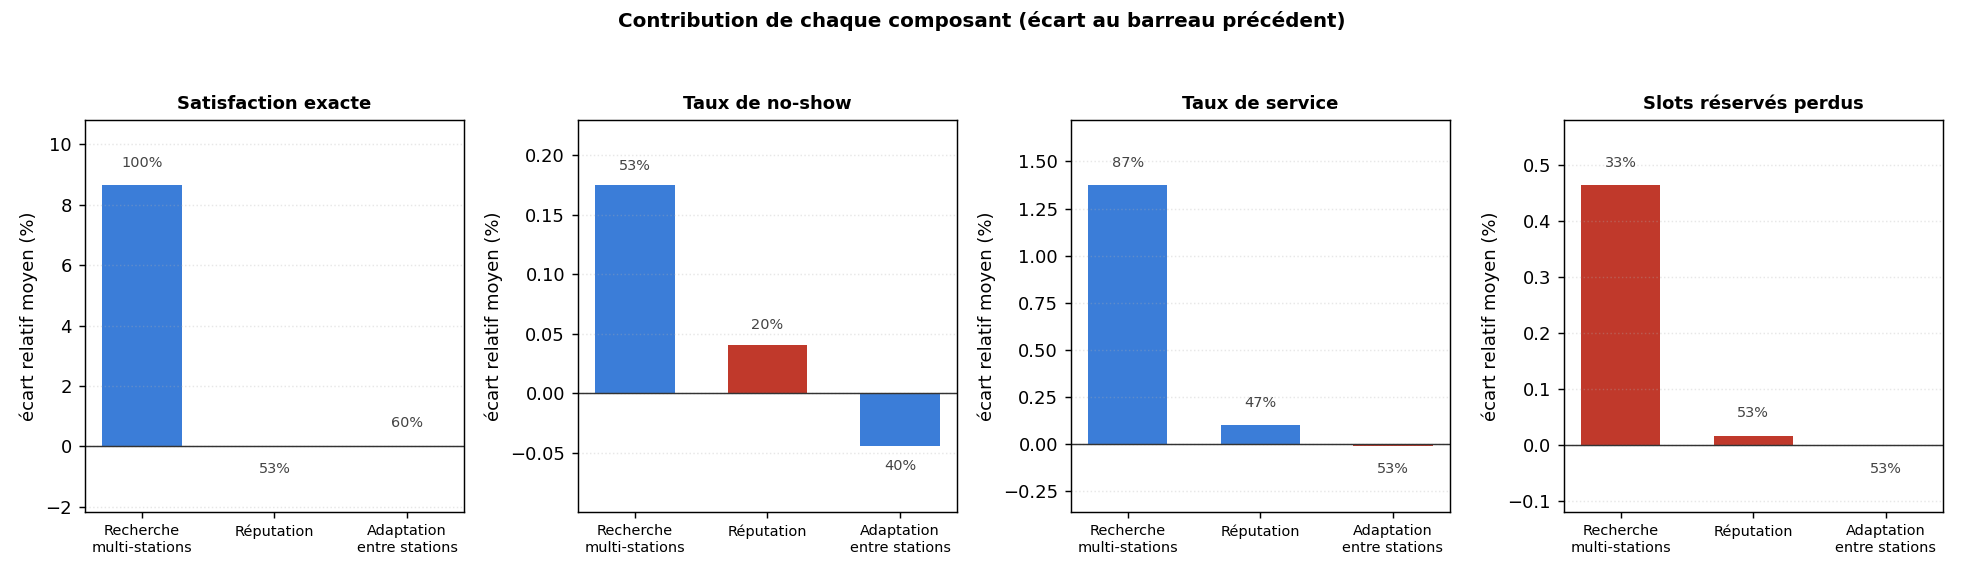

scalability.png


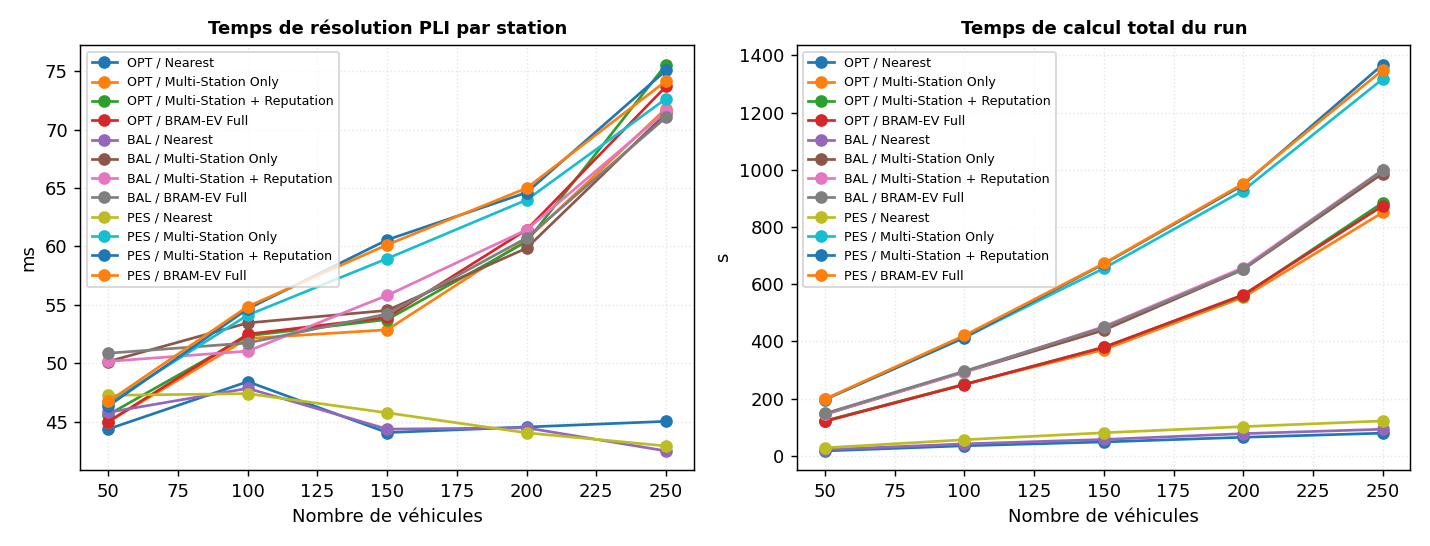

ablation_ladder_balance.png


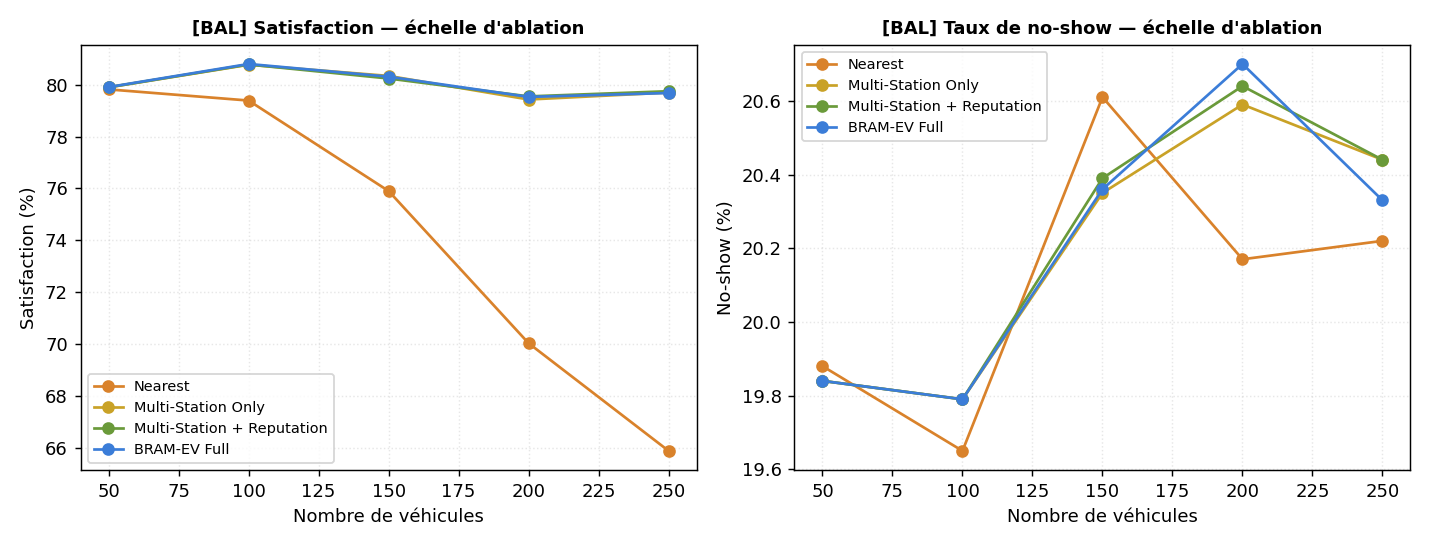

ablation_ladder_optimistic.png


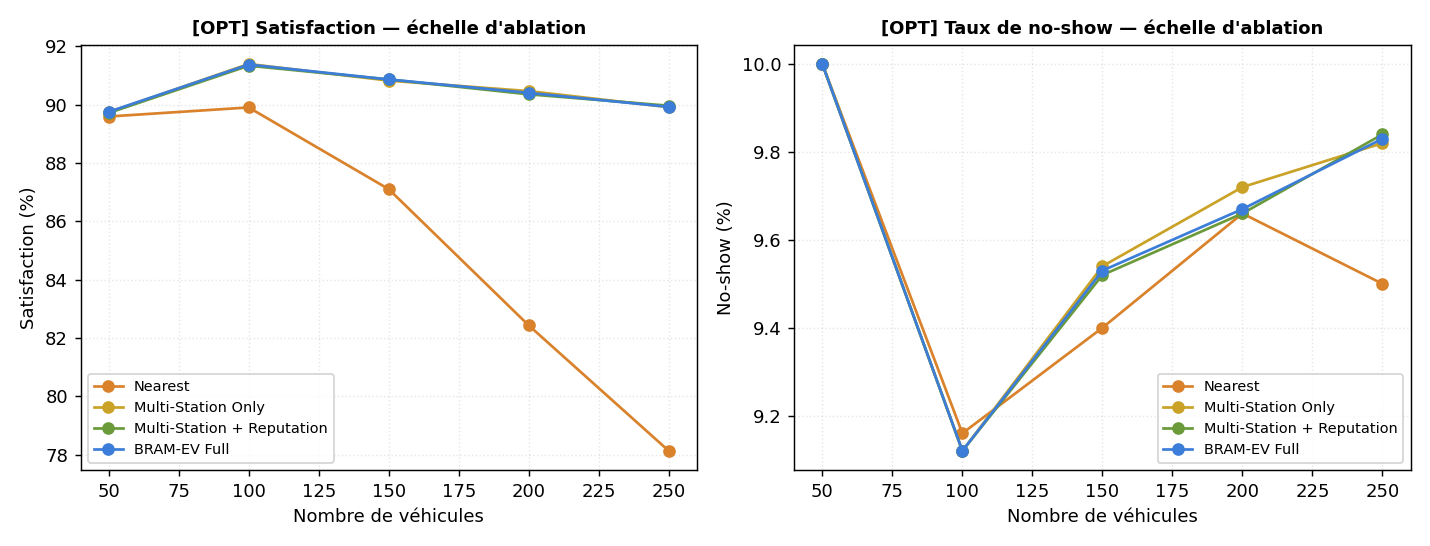

ablation_ladder_pessimistic.png


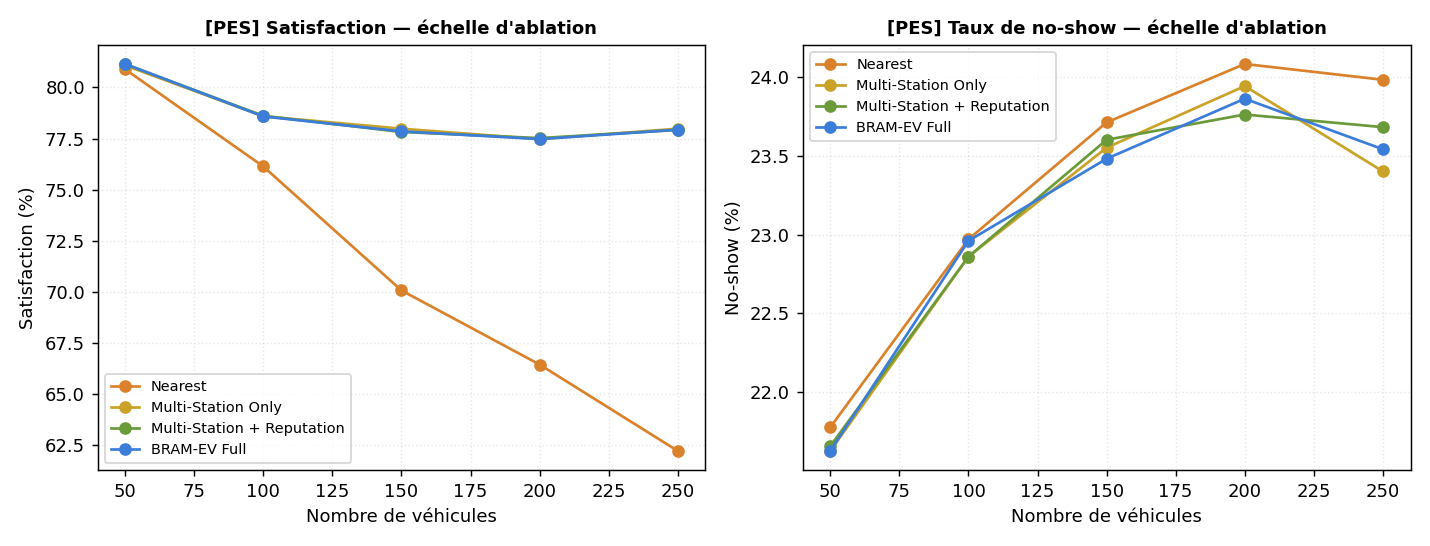

In [14]:
for nom in ['ablation_components', 'scalability']:
    chemin = store.figure_path(nom)
    if chemin.is_file():
        print(chemin.name)
        display(Image(filename=str(chemin)))

for chemin in sorted(store.figures_dir.glob('ablation_ladder_*.png')):
    print(chemin.name)
    display(Image(filename=str(chemin)))

In [21]:
# Ou reconstruire une figure en mémoire, sans repasser par le disque.
figures.fig_ablation_components(summary.to_dict('records'))

<Figure size 1510x440 with 4 Axes>

## Garde-fous de lecture

Deux composants ne peuvent structurellement rien montrer sur une campagne trop
courte ou trop peu contrainte. Un `+0.0%` doit alors se lire « mécanisme jamais
sollicité », pas « composant inutile ».

1. **L'adaptation entre stations** ne se déclenche que tous les
   `SOCIETY_UPDATE_INTERVAL` slots (144 par défaut, 12 h).
2. **La recherche multi-stations** n'a d'effet que si la requête atteint
   effectivement plus d'une station, et que la capacité est contrainte : avec
   des bornes libres partout, toute demande est servie de toute façon.

In [16]:
config = next(store.iter_results())['config']
intervalle = config['society_update_interval']
mises_a_jour = params.total_time // intervalle

print(f"horizon = {params.total_time} slots | "
      f"intervalle d'adaptation = {intervalle} slots")
print(f"-> l'apprentissage collectif se déclenche {mises_a_jour} fois")
if mises_a_jour == 0:
    print("   ATTENTION : jamais déclenché — la contribution mesurée de "
          "l'adaptation est nulle par construction.")

horizon = 1440 slots | intervalle d'adaptation = 144 slots
-> l'apprentissage collectif se déclenche 10 fois


In [17]:
diffusion = (ladder.groupby('method', observed=True)
                   .agg(offres_par_demande=('mean_offers_per_demand', 'mean'),
                        taux_de_service=('mean_service_rate', 'mean'),
                        demandes_rejetees=('nb_station_level_rejections', 'mean'))
                   .round(3))
print(diffusion, end='\n\n')

gain_offres = (diffusion.loc['multistation', 'offres_par_demande']
               - diffusion.loc['greedy', 'offres_par_demande'])
if gain_offres <= 0:
    print("ATTENTION : la diffusion ne produit pas plus d'offres par demande. "
          "Le rayon de recherche est trop petit devant l'espacement des "
          "stations : le premier barreau n'est pas testé.")
else:
    print(f"La diffusion apporte {gain_offres:+.2f} offre(s) par demande.")

                  offres_par_demande  taux_de_service  demandes_rejetees
method                                                                  
greedy                         0.980            0.107            262.667
multistation                   6.160            0.109            511.533
multistation_rep               6.142            0.109            458.667
bramev                         6.158            0.109            577.467

La diffusion apporte +5.18 offre(s) par demande.


## Santé du run

Un invariant violé ou un diagnostic massif rend toute conclusion suspecte :
à vérifier avant de citer un chiffre.

In [18]:
print('invariants OK :', bool(summary['invariant_ok'].all()))
print('réservations non résolues :', int(summary['nb_unresolved'].sum()))
print('pannes :', int(summary['nb_breakdowns'].sum()))

vus = set()
for resultat in store.iter_results():
    for message in resultat['behaviors'].get('diagnostics', []):
        if message not in vus:
            vus.add(message)
            print(f"\n[diagnostic] {message}")

invariants OK : True
réservations non résolues : 7
pannes : 0
